In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy import stats

## Inputs

In [2]:
### Inputs ###

ticker = '^GSPC'
confidence_level = 0.99
n_sims = 100000
T = 1  # horizon en jours

### Fetch Data ###

df = yf.download(tickers = ticker, start = '2000-01-01', interval = '1d')['Close']
df['Returns'] =np.log(df/df.shift(1))
df = df.dropna() 

[*********************100%***********************]  1 of 1 completed


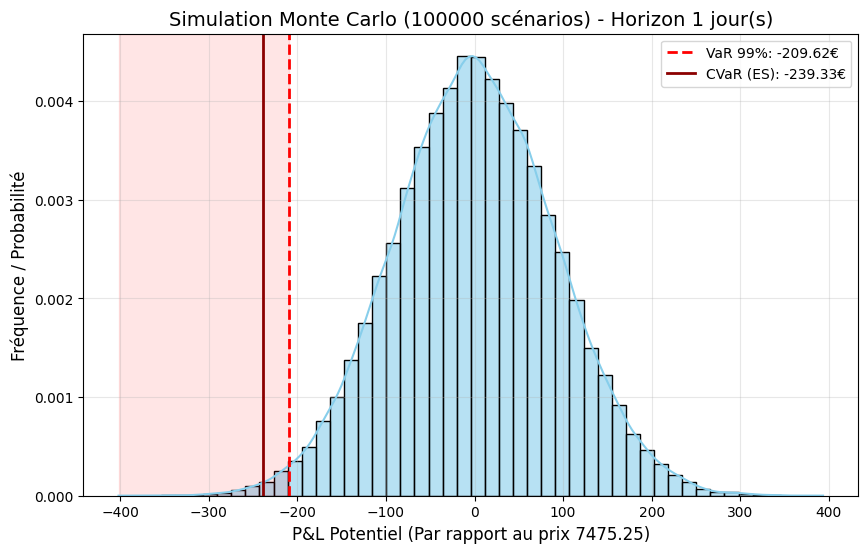

In [3]:
# Monte-Carlo

S0 = df[ticker].iloc[-1].item()
mu = 0
sigma_daily = df['Returns'].std()  # vol daily, pas annualisée

Z = np.random.normal(0, 1, n_sims)

# GBM sur T jours (sigma daily, T en jours)
S_T = S0 * np.exp((mu - 0.5 * sigma_daily**2) * T + sigma_daily * np.sqrt(T) * Z)

sim_pnl = S_T - S0
sorted_pnl = np.sort(sim_pnl)

# VaR : percentile exact
var_value = np.percentile(sorted_pnl, (1 - confidence_level) * 100)
cvar_value = sorted_pnl[sorted_pnl <= var_value].mean()

# Plot
plt.figure(figsize=(10, 6))

# Histogramme de la distribution
sns.histplot(sim_pnl, bins=50, kde=True, color="skyblue", stat="density", alpha=0.6)

# Ligne VaR
plt.axvline(var_value, color='red', linestyle='--', linewidth=2, label=f'VaR {confidence_level*100:.0f}%: {var_value:.2f}€')

# Ligne CVaR
plt.axvline(cvar_value, color='darkred', linestyle='-', linewidth=2, label=f'CVaR (ES): {cvar_value:.2f}€')
plt.axvspan(min(sim_pnl), var_value, color='red', alpha=0.1)

plt.title(f"Simulation Monte Carlo ({n_sims} scénarios) - Horizon {T} jour(s)", fontsize=14)
plt.xlabel(f"P&L Potentiel (Par rapport au prix {S0:.2f})", fontsize=12)
plt.ylabel("Fréquence / Probabilité", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

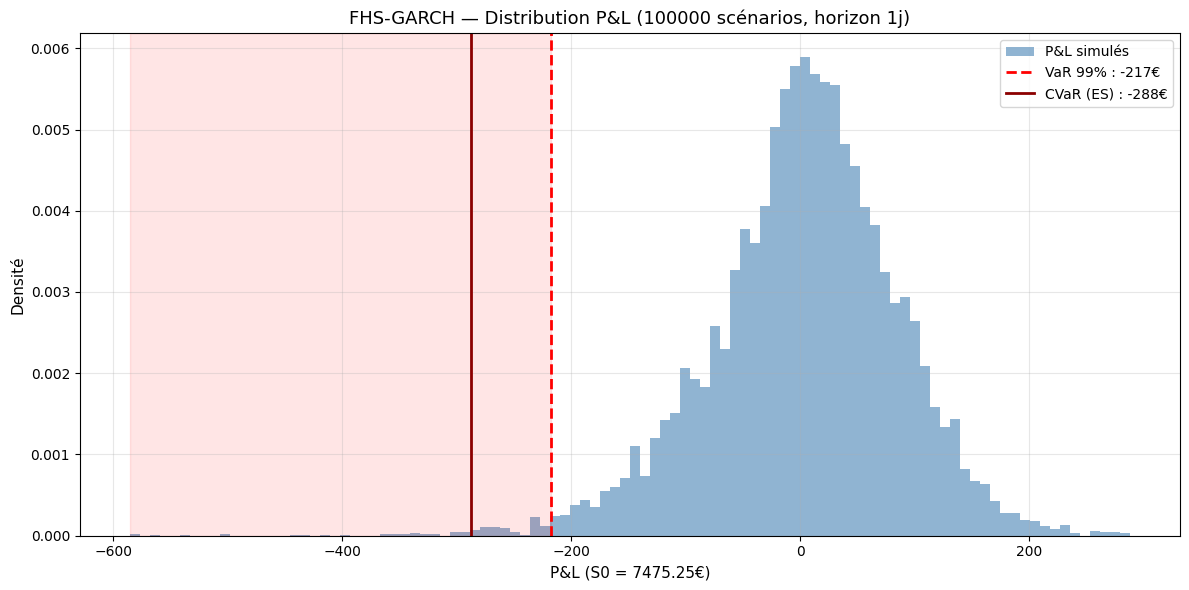

In [4]:
model = arch_model(df['Returns'] * 100, vol='GARCH', p=1, o=1, q=1, dist='t')
# o=1 → terme asymétrique GJR
res = model.fit(disp='off')

horizon_days = T

df['historical_vol'] = res.conditional_volatility

standardized_residuals = (df['Returns']*100) / df['historical_vol']

forecast = res.forecast(horizon = horizon_days, reindex = False)
next_day_vol = np.sqrt(forecast.variance.values[-1, :horizon_days].sum())

random_shocks = np.random.choice(standardized_residuals, size=(n_sims, horizon_days), replace=True)
simulated_returns = random_shocks.sum(axis=1) * next_day_vol  # → vecteur (n_sims,)

S0 = df[ticker].iloc[-1].item()
simulated_prices = S0 * np.exp(simulated_returns / 100)  # → vecteur (n_sims,)
simulated_pnl = simulated_prices - S0

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(simulated_pnl, bins=100, density=True, alpha=0.6, color='steelblue', label='P&L simulés')

var_value = np.percentile(simulated_pnl, 1)
cvar_value = simulated_pnl[simulated_pnl <= var_value].mean()

ax.axvline(var_value, color='red', linestyle='--', linewidth=2, label=f'VaR 99% : {var_value:.0f}€')
ax.axvline(cvar_value, color='darkred', linestyle='-', linewidth=2, label=f'CVaR (ES) : {cvar_value:.0f}€')
ax.axvspan(simulated_pnl.min(), var_value, color='red', alpha=0.1)

ax.set_title(f'FHS-GARCH — Distribution P&L ({n_sims} scénarios, horizon {horizon_days}j)', fontsize=13)
ax.set_xlabel(f'P&L (S0 = {S0:.2f}€)', fontsize=11)
ax.set_ylabel('Densité', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()